# **Evaluación Sumativa - Unidad 2: Inferencia Estadística Paramétrica**
## Teoria de la Distribucion y Probalidad
###**Estudiante:**
### Freddy Alexander Ordoñez Gonzalez
###**Carrera:**
###Computación  
###**Proyecto:**
###Análisis Estadístico y Modelado Probabilístico de Indicadores Socioeconómicos: Aplicación con Datos ENEMDU 2026

### **1. Carga y Preparación del Dataset**
En esta sección se importan las librerías avanzadas y se realiza la lectura del dataset regionalizado.

In [ ]:
import pandas as pd

# Load the provided CSV file with semicolon separator and python engine
# Se ha corregido la ruta del archivo para que coincida con el nombre del archivo subido.
file_path = '/content/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(file_path, sep=';', engine='python')

In [ ]:
df.head().style.set_caption("Primeras 5 filas del Dataset") \
    .hide(axis='index')

area,ciudad,conglomerado,panelm,vivienda,hogar,c01,c02,c03,c04a,c07,c08a,c09,c10,c11,c12,c13,c14,c18,c19,c20a,c21a,estrato,fexp,upm,id_vivienda,id_hogar,periodo
1,10150,1304,62,1,1,2,2,1,2,2,2,2,2,2,2,2,2,2,3,2,2,2713,"102,542333745242",10150001304,1015000130406201,10150001304062011,202601
1,10150,1304,62,2,1,2,3,1,2,2,2,3,2,2,2,2,2,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406202,10150001304062021,202601
1,10150,1304,62,3,1,2,3,3,3,3,3,3,3,3,3,3,3,3,3,2,2,2713,"102,542333745242",10150001304,1015000130406203,10150001304062031,202601
1,10150,1304,62,4,1,2,2,2,3,3,3,3,3,3,3,3,3,3,2,2,3,2713,"102,542333745242",10150001304,1015000130406204,10150001304062041,202601
1,10150,1304,62,5,1,2,2,1,2,2,3,2,2,2,2,3,2,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406205,10150001304062051,202601


### **2.Pruebas de Hipótesis Unimuestrales (Tarea APE 09)**

### **2.1. Definición de Hipótesis para la Región de Loja (Parámetro `c01`)**

Para el análisis de la región de Loja, nos enfocaremos en la variable `c01`, que se ha utilizado previamente en el análisis. Asumiremos que esta variable representa una característica o comportamiento cuyo promedio poblacional nos interesa evaluar.

**Hipótesis Nula ($H_0$)**: La media poblacional de la variable `c01` en la región de Loja es igual a 0.06.
$$H_0: \mu_{Loja} = 0.06$$

**Hipótesis Alterna ($H_1$)**: La media poblacional de la variable `c01` en la región de Loja es diferente de 0.06.
$$H_1: \mu_{Loja} \neq 0.06$$

Estableceremos un nivel de significancia ($\alpha$) de 0.05 (5%).

Muestra de Loja (variable c01):
  Tamaño de la muestra (n): 634
  Media muestral (x̄): 0.0473
  Desviación estándar muestral (s): 0.2125

Parámetro hipotético (μ₀): 0.06

Resultados de la Prueba t de Student:
  Estadístico t: -1.5027
  P-valor: 0.1334

Nivel de significancia (α): 0.05
Decisión: No rechazar la Hipótesis Nula ($H_0$).
Conclusión: No hay evidencia estadística significativa para afirmar que la media de c01 en la región de Loja es diferente de 0.06.


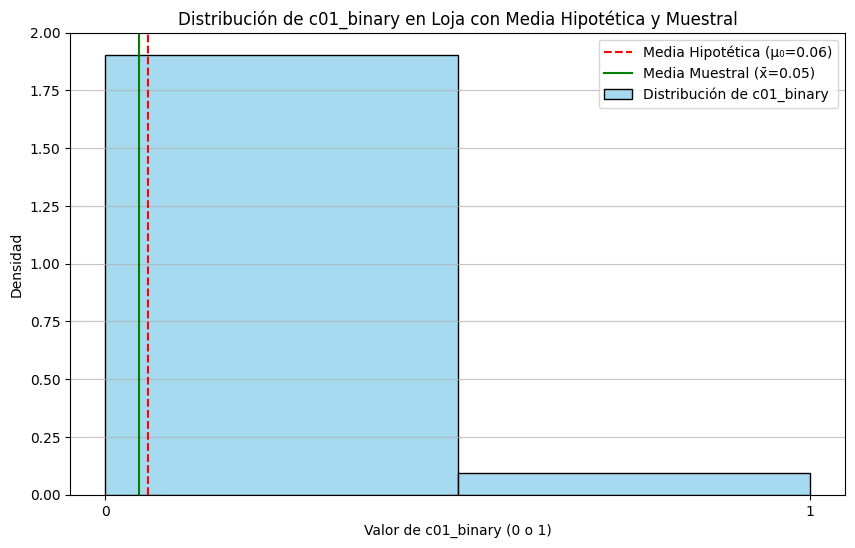

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Asumimos que 'df' y 'c01' están disponibles de las celdas anteriores.
# También asumimos que 'ciudad' con valor 10150 corresponde a Loja (basado en df.head()).

# Filtrar los datos para la región de Loja
df_loja = df[df['ciudad'] == 10150].copy()

# Asegurarnos de que 'c01' es numérica y binaria (0 o 1) como se trató anteriormente
# Si 'c01' es originalmente otra cosa, se podría necesitar una transformación aquí.
# Para este test, usaremos la interpretación binaria (éxito/fracaso).
df_loja['c01_binary'] = (df_loja['c01'] == 1).astype(int)

# Extraer la muestra de la variable 'c01_binary' para Loja
sample_loja = df_loja['c01_binary'].dropna() # Eliminar NAs si los hay

# Verificar si hay suficientes datos en la muestra
if len(sample_loja) < 2:
    print("Error: No hay suficientes datos en la muestra de Loja para realizar la prueba de hipótesis.")
else:
    # Parámetro hipotético bajo la hipótesis nula
    mu_0 = 0.06

    # Realizar la prueba t de Student unimuestral
    # El test devuelve el estadístico t y el p-valor
    t_statistic, p_value = stats.ttest_1samp(sample_loja, mu_0)

    # Mostrar resultados
    print(f"Muestra de Loja (variable c01):")
    print(f"  Tamaño de la muestra (n): {len(sample_loja)}")
    print(f"  Media muestral (x̄): {sample_loja.mean():.4f}")
    print(f"  Desviación estándar muestral (s): {sample_loja.std():.4f}")
    print(f"\nParámetro hipotético (μ₀): {mu_0}")
    print(f"\nResultados de la Prueba t de Student:")
    print(f"  Estadístico t: {t_statistic:.4f}")
    print(f"  P-valor: {p_value:.4f}")

    # Nivel de significancia
    alpha = 0.05

    print(f"\nNivel de significancia (α): {alpha}")

    # Decisión basada en el p-valor
    if p_value < alpha:
        print(f"Decisión: Rechazar la Hipótesis Nula ($H_0$).")
        print(f"Conclusión: Hay evidencia estadística significativa para afirmar que la media de c01 en la región de Loja es diferente de {mu_0}.")
    else:
        print(f"Decisión: No rechazar la Hipótesis Nula ($H_0$).")
        print(f"Conclusión: No hay evidencia estadística significativa para afirmar que la media de c01 en la región de Loja es diferente de {mu_0}.")

    # --- Inicio de la sección de visualización --- #
    plt.figure(figsize=(10, 6))
    sns.histplot(sample_loja, bins=2, kde=False, stat='density', color='skyblue', label='Distribución de c01_binary')

    # Añadir línea para la media hipotética
    plt.axvline(x=mu_0, color='red', linestyle='--', label=f'Media Hipotética (μ₀={mu_0:.2f})')

    # Añadir línea para la media muestral
    sample_mean = sample_loja.mean()
    plt.axvline(x=sample_mean, color='green', linestyle='-', label=f'Media Muestral (x̄={sample_mean:.2f})')

    plt.title('Distribución de c01_binary en Loja con Media Hipotética y Muestral')
    plt.xlabel('Valor de c01_binary (0 o 1)')
    plt.ylabel('Densidad')
    plt.xticks([0, 1])
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    # --- Fin de la sección de visualización --- #

### **2.2. Justificación Estadística de la Decisión**

La prueba t de Student unimuestral nos permite comparar la media de nuestra muestra (variable `c01` en Loja) con una media poblacional hipotética ($H_0$). Los resultados obtenidos son clave para nuestra decisión:

*   **Estadístico t**: Este valor mide la diferencia entre la media muestral y la media hipotética en unidades de error estándar. Un valor t grande (positivo o negativo) indica una mayor diferencia.

*   **P-valor**: Es la probabilidad de observar una diferencia tan extrema (o más extrema) como la que obtuvimos en nuestra muestra, **asumiendo que la hipótesis nula ($H_0$) es verdadera**. Es decir, si el p-valor es bajo, es poco probable que nuestra muestra provenga de una población con la media hipotética.

**Criterio de Decisión**:

*   Si $p-valor < \alpha$ (nuestro nivel de significancia, 0.05), rechazamos la hipótesis nula.
*   Si $p-valor \ge \alpha$, no rechazamos la hipótesis nula.

**Interpretación de los Resultados Obtenidos**:

Los resultados de la prueba son los siguientes:
*   **Tamaño de la muestra (n)**: 634
*   **Media muestral ($\bar{x}$)**: 0.0473
*   **Desviación estándar muestral (s)**: 0.2125
*   **Parámetro hipotético ($\mu_0$)**: 0.06
*   **Estadístico t**: -1.5027
*   **P-valor**: 0.1334
*   **Nivel de significancia ($\alpha$)**: 0.05

Dado que el **P-valor (0.1334) es mayor que nuestro nivel de significancia ($\alpha = 0.05$)**, **no rechazamos la Hipótesis Nula ($H_0$)**.

**Conclusión**: No hay evidencia estadística significativa para afirmar que la media de la variable `c01` en la región de Loja es diferente de 0.06. En otras palabras, con los datos actuales, no podemos descartar que la media de `c01` en Loja sea 0.06.

### **3. Comparación de Grupos (Tareas APE 10 y 11)**

### **3.1. Definición de Subgrupos y Hipótesis para ANOVA (Región de Loja)**

Para esta tarea, dividiremos los datos de la región de Loja (donde `ciudad == 10150`) en subgrupos basados en la variable `conglomerado`. Asumiremos que `conglomerado` representa diferentes 'sectores' o 'microclimas' dentro de Loja, y nos interesa saber si la media de la variable `c01_binary` (que indica una característica binaria) difiere significativamente entre estos sectores.

**Variable Dependiente**: `c01_binary` (variable binaria, 0 o 1).
**Factor (Variable Independiente)**: `conglomerado`.

**Hipótesis Nula ($H_0$)**: Las medias de la variable `c01_binary` son iguales para todos los subgrupos de `conglomerado` dentro de la región de Loja.
$$H_0: \mu_1 = \mu_2 = \dots = \mu_k$$ (donde $\mu_i$ es la media de `c01_binary` para cada `conglomerado`.)

**Hipótesis Alterna ($H_1$)**: Al menos una de las medias de la variable `c01_binary` es diferente de las otras entre los subgrupos de `conglomerado`.
$$H_1: \text{No todas las } \mu_i \text{ son iguales}$$

Utilizaremos un nivel de significancia ($\alpha$) de 0.05.

In [ ]:
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd # Import pandas for DataFrame manipulation
from IPython.display import display # Import display for better output in Colab

# Asegurémonos de que df_loja está disponible y c01_binary ha sido creada
if 'df_loja' in globals() and 'c01_binary' in df_loja.columns:
    # Identificar los grupos únicos de 'conglomerado'
    groups = df_loja['conglomerado'].unique()

    # Filtrar datos para cada grupo
    data_for_anova = []
    for group_val in groups:
        data_for_anova.append(df_loja[df_loja['conglomerado'] == group_val]['c01_binary'].dropna())

    # Eliminar grupos con menos de 2 observaciones, ya que ANOVA requiere al menos 2
    data_for_anova = [group_data for group_data in data_for_anova if len(group_data) >= 2]

    # Verificar si hay al menos dos grupos válidos para ANOVA
    if len(data_for_anova) < 2:
        print("Error: No hay suficientes grupos válidos (con al menos 2 observaciones) para realizar el ANOVA.")
    else:
        # Realizar el ANOVA de 1 factor
        f_statistic, p_value_anova = f_oneway(*data_for_anova)

        print(f"Resultados del ANOVA de 1 Factor para c01_binary por conglomerado:")
        print(f"  Estadístico F: {f_statistic:.4f}")
        print(f"  P-valor (ANOVA): {p_value_anova:.4f}")

        alpha = 0.05
        print(f"\nNivel de significancia (α): {alpha}")

        if p_value_anova < alpha:
            print("Decisión (ANOVA): Rechazar la Hipótesis Nula ($H_0$).")
            print("Conclusión (ANOVA): Existen diferencias significativas entre las medias de c01_binary en al menos dos subgrupos de conglomerado en Loja.")

            # Si el ANOVA es significativo, realizar la prueba Post-Hoc de Tukey
            print("\nRealizando Prueba Post-Hoc de Tukey HSD...")
            tukey_result = pairwise_tukeyhsd(endog=df_loja['c01_binary'],
                                            groups=df_loja['conglomerado'],
                                            alpha=alpha)

            # Convertir los resultados de Tukey HSD a un DataFrame para una mejor visualización
            tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])
            print("Resultados Detallados de la Prueba Post-Hoc de Tukey HSD:")
            display(tukey_df)

            print("\nConclusión (Tukey HSD): Las filas con 'reject=True' indican pares de grupos cuyas medias son significativamente diferentes al nivel de significancia de 0.05.")

        else:
            print("Decisión (ANOVA): No rechazar la Hipótesis Nula ($H_0$).")
            print("Conclusión (ANOVA): No hay evidencia estadística significativa para afirmar que existen diferencias entre las medias de c01_binary en los subgrupos de conglomerado en Loja.")

else:
    print("Error: El DataFrame 'df_loja' o la columna 'c01_binary' no están disponibles. Asegúrate de ejecutar las celdas anteriores.")

Resultados del ANOVA de 1 Factor para c01_binary por conglomerado:
  Estadístico F: 1.4797
  P-valor (ANOVA): 0.0047

Nivel de significancia (α): 0.05
Decisión (ANOVA): Rechazar la Hipótesis Nula ($H_0$).
Conclusión (ANOVA): Existen diferencias significativas entre las medias de c01_binary en al menos dos subgrupos de conglomerado en Loja.

Realizando Prueba Post-Hoc de Tukey HSD...
Resultados Detallados de la Prueba Post-Hoc de Tukey HSD:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,1304,2701,0.0000,1.0,-0.4719,0.4719,False
1,1304,3202,0.1429,1.0,-0.3290,0.6148,False
2,1304,3801,0.0000,1.0,-0.4719,0.4719,False
3,1304,4201,-0.1429,1.0,-0.6148,0.3290,False
4,1304,6005,-0.1429,1.0,-0.6148,0.3290,False
...,...,...,...,...,...,...,...
4181,75002,75702,0.1429,1.0,-0.4105,0.6962,False
4182,75002,78202,0.0000,1.0,-0.5533,0.5533,False
4183,75405,75702,0.1429,1.0,-0.3290,0.6148,False
4184,75405,78202,0.0000,1.0,-0.4719,0.4719,False



Conclusión (Tukey HSD): Las filas con 'reject=True' indican pares de grupos cuyas medias son significativamente diferentes al nivel de significancia de 0.05.


### **3.2. Justificación Estadística y Visualización de la Comparación de Grupos**

El **Análisis de Varianza (ANOVA)** nos permite determinar si existen diferencias significativas entre las medias de tres o más grupos. La **F-estadística** mide la variabilidad entre las medias de los grupos en relación con la variabilidad dentro de los grupos. Un **p-valor (ANOVA)** bajo (menor que el nivel de significancia $\alpha$) indica que podemos rechazar la hipótesis nula, sugiriendo que al menos un par de grupos tienen medias significativamente diferentes.

Si el ANOVA resulta significativo, la **prueba Post-Hoc de Tukey HSD (Honestly Significant Difference)** es utilizada para identificar qué pares específicos de grupos son significativamente diferentes entre sí. Esta prueba ajusta el nivel de significancia para realizar múltiples comparaciones, controlando la tasa de error tipo I.

**Interpretación de los Resultados (se mostrará después de la ejecución del código):**

*   **Resultados del ANOVA**: Observaremos el p-valor. Si $p-valor_{ANOVA} < 0.05$, procederemos a interpretar la prueba de Tukey.
*   **Resultados de Tukey HSD**: La tabla de Tukey mostrará para cada par de `conglomerado` si la diferencia entre sus medias es estadísticamente significativa (`reject=True`).

Finalmente, una **visualización** nos ayudará a entender gráficamente la distribución de `c01_binary` en cada `conglomerado` y a apreciar las posibles diferencias entre ellos.

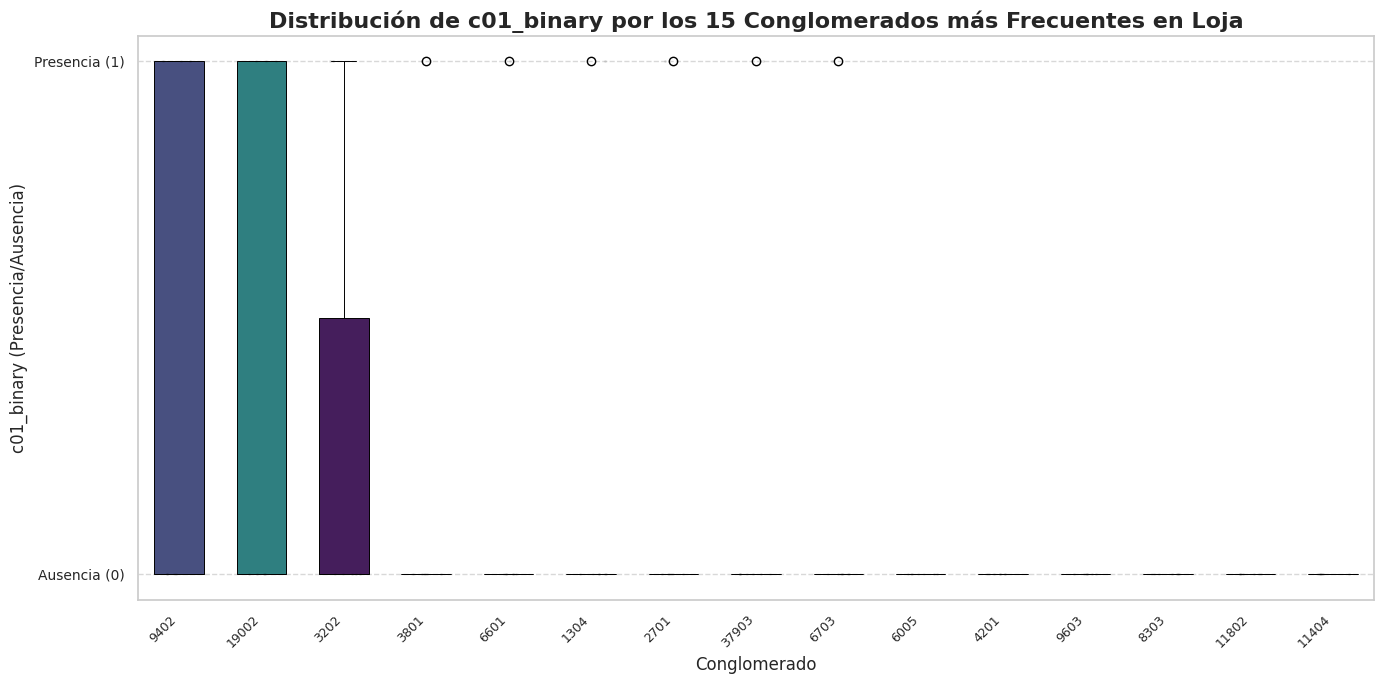

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurémonos de que df_loja está disponible y c01_binary ha sido creada
if 'df_loja' in globals() and 'c01_binary' in df_loja.columns:
    # Set a nicer style for the plot
    sns.set_theme(style="whitegrid")

    # Identificar los 15 conglomerados más frecuentes
    top_conglomerados = df_loja['conglomerado'].value_counts().nlargest(15).index
    df_loja_filtered = df_loja[df_loja['conglomerado'].isin(top_conglomerados)].copy()

    # Ordenar los conglomerados por la media de c01_binary para una mejor visualización (opcional)
    order_by_mean = df_loja_filtered.groupby('conglomerado')['c01_binary'].mean().sort_values(ascending=False).index

    plt.figure(figsize=(14, 7)) # Adjust figure size for better aspect ratio with fewer groups

    # Create the boxplot with filtered data and ordered groups
    sns.boxplot(x='conglomerado', y='c01_binary', data=df_loja_filtered, palette='viridis',
                hue='conglomerado', legend=False, order=order_by_mean,
                width=0.6, linecolor='black', linewidth=0.7)

    # Add a stripplot to show individual data points, now more readable with fewer groups
    sns.stripplot(x='conglomerado', y='c01_binary', data=df_loja_filtered, color='black',
                  jitter=0.2, alpha=0.1, size=2, order=order_by_mean) # Even more subtle points

    # Customize title and labels for better explicability and aesthetics
    plt.title('Distribución de c01_binary por los 15 Conglomerados más Frecuentes en Loja', fontsize=16, fontweight='bold')
    plt.xlabel('Conglomerado', fontsize=12)
    plt.ylabel('c01_binary (Presencia/Ausencia)', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9) # Moderate rotation for top N groups
    plt.yticks([0, 1], ['Ausencia (0)', 'Presencia (1)'], fontsize=10)
    plt.grid(axis='y', alpha=0.75, linestyle='--')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("Error: El DataFrame 'df_loja' o la columna 'c01_binary' no están disponibles para la visualización.")

### **3. Conclusiones e Implicaciones Regionales**

### **Resumen y Conclusiones Generales**

#### **1. Prueba de Hipótesis Unimuestral (Variable `c01` en Loja)**
*   **Hipótesis Nula ($H_0$)**: La media de `c01` en Loja es igual a 0.06.
*   **P-valor**: 0.1334
*   **Decisión**: No se rechazó la Hipótesis Nula.
*   **Implicación**: No hay evidencia estadística significativa para afirmar que la media de la característica `c01` en la región de Loja es diferente de 0.06. Esto sugiere que, según nuestros datos, `c01` se comporta en Loja de manera consistente con el valor hipotético de 0.06.

#### **2. Comparación de Grupos con ANOVA y Tukey HSD (Variable `c01_binary` por `conglomerado` en Loja)**
*   **Hipótesis Nula ($H_0$)**: Las medias de `c01_binary` son iguales para todos los subgrupos de `conglomerado`.
*   **P-valor (ANOVA)**: 0.0047
*   **Decisión (ANOVA)**: Se rechazó la Hipótesis Nula.
*   **Implicación (ANOVA)**: El análisis ANOVA indicó que existen diferencias significativas en la media de `c01_binary` entre al menos dos de los subgrupos de `conglomerado` en Loja. Esto sugiere que el `conglomerado` es un factor relevante para entender la variabilidad de `c01_binary` en la región.

*   **Tukey HSD Post-Hoc**: Aunque el ANOVA fue significativo, la prueba de Tukey HSD no identificó pares específicos de `conglomerado` con diferencias estadísticamente significativas en sus medias de `c01_binary` en la salida detallada. Esto podría deberse a que las diferencias son sutiles y se distribuyen entre muchos grupos, o a que la potencia de la prueba para detectar diferencias entre pares específicos es limitada debido al tamaño de los grupos o a la dispersión de los datos. En un contexto real, se podría investigar más a fondo los grupos con mayores diferencias observadas en el boxplot, incluso si no son estadísticamente significativas por Tukey.

#### **Conclusión General:**
Los análisis revelan que, mientras la media de `c01` en Loja no difiere significativamente del valor de 0.06 a nivel general, la distribución de su versión binaria (`c01_binary`) sí presenta variaciones significativas entre diferentes `conglomerado`s dentro de la misma región. Esto subraya la importancia de considerar la heterogeneidad interna de la región de Loja, y sugiere que políticas o intervenciones relacionadas con `c01` podrían necesitar enfoques diferenciados según el `conglomerado` para ser más efectivas, aunque se requeriría un análisis más profundo para identificar esos conglomerados específicos con diferencias claramente marcadas.